# The privatization vs. nationalization debate in legislative programs

# Imports

In [1]:
import pandas as pd
import numpy as np
import os
import re
from tqdm import tqdm
from time import sleep
from IPython.display import clear_output
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import  LatentDirichletAllocation 
import matplotlib.pyplot as plt
import requests
from re import findall
from transformers import AutoTokenizer, AutoModelForSequenceClassification  # Loading pretrained BERT/DistilBERT models
import torch
import geopandas as gpd
from cartiflette import carti_download
import warnings
warnings.filterwarnings("ignore")


# Data pre-processing

## Creating a dataframe of the texts studied

We start by collecting the data for the three elections: 1981, 1988 and 1993.

In [ ]:
def preprocessing(path, df, year, i):
    """
        Scans a directory for programs and creates a dataframe with each manifesto in a row.
    """
    for title in os.scandir(path):
        f=open(title, "r", encoding="utf-8")
        text=str(f.readlines())
        
        # some pre-processing
        if text!="[]":
            text=re.sub("\[", "", text)
            text=re.sub("\]", "", text)
            text=re.sub("Sciences Po / fonds CEVIPOF", "", text)
            text=text.replace("\\n", "")
            text=re.sub("- ", "", text)
            text=text.replace("\\", "")
            text=text.replace("*' ", "")
            text=text.replace(" '*", "")
            text=text.replace(",", "")
            text=text.replace('"', "")
            text=text.lower()
            
            df.loc[i, "name"]=str(title.name)[:-4]
            df.loc[i, "text"]=text
            df.loc[i, "year"]=year
            i+=1
            
    return df, i

In [3]:
# Creating a df to store the data
df=pd.DataFrame({"name":[], "year":[], "text":[]})
df["name"]=df["name"].astype(str)
df["text"]=df["text"].astype(str)
df["year"]=df["year"].astype(int)

In [ ]:
df,i=preprocessing("data/texts-1981", df, 1981, 0)
df,i=preprocessing("data/texts-1988", df, 1988, i)
df,i=preprocessing("data/texts-1993", df, 1993, i)

In [ ]:
df["name"].nunique()

12746

Now we add some metadata: the names and party affiliation of the candidates.

In [ ]:
# Load the metadata
metadata_1981=pd.read_csv("data/metadata-1981.csv", usecols=["id", "departement-nom", "titulaire-nom", "titulaire-prenom", "titulaire-soutien", "titulaire-liste", "suppleant-nom", "suppleant-prenom", "suppleant-soutien", "suppleant-liste"])
metadata_1988=pd.read_csv("data/metadata-1988.csv", usecols=["id", "departement-nom", "titulaire-nom", "titulaire-prenom", "titulaire-soutien", "titulaire-liste", "suppleant-nom", "suppleant-prenom", "suppleant-soutien", "suppleant-liste"])
metadata_1993=pd.read_csv("data/metadata-1993.csv", usecols=["id", "departement-nom", "titulaire-nom", "titulaire-prenom", "titulaire-soutien", "titulaire-liste", "suppleant-nom", "suppleant-prenom", "suppleant-soutien", "suppleant-liste"])

In [ ]:
metadata_1981=metadata_1981.rename(columns={"id":"name"})
metadata_1988=metadata_1988.rename(columns={"id":"name"})
metadata_1993=metadata_1993.rename(columns={"id":"name"})

In [ ]:
metadata_1981["name"]=metadata_1981["name"].astype(str)
metadata_1988["name"]=metadata_1988["name"].astype(str)
metadata_1993["name"]=metadata_1993["name"].astype(str)

In [ ]:
metadata=pd.concat([metadata_1981, metadata_1988, metadata_1993], axis=0)

In [ ]:
# Add the metadata to the main df
df=df.merge(metadata, on="name")

Finally we add a first filter to select the programs that use one of the terms studied: nationalization, etatization and privatization. Lemmatizing every single program seems too costly and not efficient enough in our situation.

In [ ]:
# Tag programs that mention nationalization or privatization
keywords_nat=[" nationalise", " nationalisé", " nationalisa", " nationaliso", 
          " étatise", " étatisa", ' étatisé', " étatiso",
          " etatise", " etatisa", " etatisé", " etatiso",
             "déprivatise", "déprivatisa", "déprivatisé", "déprivatiso"]
keywords_priv=[" privatise", " privatisa", " privatisé", " privatiso",
              "dénationalise", "dénationalisé", "dénationalisa", "dénationaliso"
              "désétatise", "désétatisa", 'désétatisé', "désétatiso",
          "desetatise", "desetatisa", "desetatisé", "desetatiso"]

In [ ]:
for i in range(len(df)):
    if any(word in df.loc[i, "text"] for word in keywords_nat):
        df.loc[i, "nat"]=True
    else:
        df.loc[i, "nat"]=False
    if any(word in df.loc[i, "text"] for word in keywords_priv):
        df.loc[i, "priv"]=True
    else:
        df.loc[i, "priv"]=False

In [ ]:
df.to_csv("data/data.csv")

In [ ]:
df2=df[(df["nat"]==True) | (df["priv"]==True)]
df2.reset_index(inplace=True)

## Add political affiliation

In [288]:
df2["affiliation"]={}

In [289]:
# rough filters
keywords_fl=["communiste", "marxiste", "parti des travailleurs"]
keywords_l=["socialiste", "vert", "écolo", "gauche"]
keywords_r=["rassemblement pour la république", "union pour la démocratie française", "droite", "gaulliste"]
keywords_fr=["front national"]
keywords_u=["indépendant", "non mentionné", "aucun parti politique", "sans parti politique", "sans étiquette"]


for i in tqdm(range(len(df2))):
    if any(word in df2.loc[i, "titulaire-soutien"].lower() for word in keywords_fl):
        df2.loc[i, "affiliation"]="far-left"
    elif any(word in df2.loc[i, "titulaire-soutien"].lower() for word in keywords_l):
        df2.loc[i, "affiliation"]="left"
    elif any(word in df2.loc[i, "titulaire-soutien"].lower() for word in keywords_r):
        df2.loc[i, "affiliation"]="right"
    elif any(word in df2.loc[i, "titulaire-soutien"].lower() for word in keywords_fr):
        df2.loc[i, "affiliation"]="far-right"
    elif any(word in df2.loc[i, "titulaire-soutien"].lower() for word in keywords_u):
        df2.loc[i, "affiliation"]="unaffiliated"
    

100%|███████████████████████████████████████████| 1030/1030 [00:00<00:00, 2584.62it/s]


In [290]:
# precise filters 
for i in tqdm(range(len(df2))):
    if df2.loc[i, "titulaire-soutien"] in ["Nouvelle solidarité", "Mouvement pour la France", "Mouvement travail patrie"]:
        df2.loc[i, "affiliation"]="far-right"
    if df2.loc[i, "titulaire-soutien"] in ["giscardien déçu", "Centre des démocrates sociaux", "Parti républicain", "Parti libéral pour la démocratie française"]:
        df2.loc[i, "affiliation"]="right"
    if df2.loc[i, "titulaire-soutien"] in ["Radical", "Parti radical"]:
        df2.loc[i, "affiliation"]="center"
    if df2.loc[i, "titulaire-soutien"] in ["Union démocratique bretonne", "social-démocrate"]:
        df2.loc[i, "affiliation"]="left"
    if df2.loc[i, "titulaire-soutien"] in ["Ligue trotskyste", "Union de la jeunesse et des créateurs", "Alliance européenne des travailleurs"]:
        df2.loc[i, "affiliation"]="far-left"
    if df2.loc[i, "titulaire-soutien"]=="Faatereraa tiama o polinesia maohi":
        df2.loc[i, "affiliation"]="unaffiliated"

100%|███████████████████████████████████████████| 1030/1030 [00:00<00:00, 5227.99it/s]


We can also add dummies representing the most important parties (parties that support a significant share of the candidates).

In [291]:
df2["pcf"]=df2["titulaire-soutien"].apply(lambda x: 1 if "parti communiste français" in x.lower() else 0)
df2["ps"]=df2["titulaire-soutien"].apply(lambda x: 1 if "parti socialiste" in x.lower() else 0)
df2["rpr"]=df2["titulaire-soutien"].apply(lambda x: 1 if "rassemblement pour la république" in x.lower() else 0)
df2["udf"]=df2["titulaire-soutien"].apply(lambda x: 1 if "union pour la démocratie française" in x.lower() else 0)

In [ ]:
df2.to_csv("data/df_programs.csv")

## Select only the phrases that mention one of the words

In [ ]:
# Only keep phrases in programs which mention one of the words
df_phrases=pd.DataFrame({"name":[], "year":[], "text":[], "locality":[], "titulaire-nom":[], "titulaire-prenom":[], "titulaire-soutien":[], 'titulaire-liste':[], "suppleant-nom":[], "suppleant-prenom":[], "suppleant-soutien":[], "suppleant-liste":[], "nat":[], "priv":[]})
df_phrases=df_phrases.astype(str)
df_phrases["year"]=df_phrases["year"].astype(int)
df_phrases["nat"]=df_phrases["nat"].astype(bool)
df_phrases["priv"]=df_phrases["priv"].astype(bool)
keywords = keywords_nat + keywords_priv

k=0
for i in tqdm(range(len(df2))):
    compteur=0
    liste_phrases=re.split(r'[.?!·]', df2.loc[i, "text"])
    
    for phrase in liste_phrases:
        if any(word in phrase for word in keywords):
            compteur+=1
            k+=1
            df_phrases.loc[k, "name"]=df2.loc[i, "name"]
            df_phrases.loc[k, "year"]=df2.loc[i, "year"]
            df_phrases.loc[k, "text"]=phrase
            df_phrases.loc[k, "locality"]=df2.loc[i, "departement-nom"]
            df_phrases.loc[k, "titulaire-nom"]=df2.loc[i, "titulaire-nom"]
            df_phrases.loc[k, "titulaire-prenom"]=df2.loc[i, "titulaire-prenom"]
            df_phrases.loc[k, "titulaire-soutien"]=df2.loc[i, "titulaire-soutien"]
            df_phrases.loc[k, "titulaire-liste"]=df2.loc[i, "titulaire-liste"]
            df_phrases.loc[k, "suppleant-nom"]=df2.loc[i, "suppleant-nom"]
            df_phrases.loc[k, "suppleant-prenom"]=df2.loc[i, "suppleant-prenom"]
            df_phrases.loc[k, "suppleant-soutien"]=df2.loc[i, "suppleant-soutien"]
            df_phrases.loc[k, "suppleant-liste"]=df2.loc[i, "suppleant-liste"]
            df_phrases.loc[k, "affiliation"]=df2.loc[i, "affiliation"]
            df_phrases.loc[k, "pcf"]=df2.loc[i, "pcf"]
            df_phrases.loc[k, "ps"]=df2.loc[i, "ps"]
            df_phrases.loc[k, "rpr"]=df2.loc[i, "rpr"]
            df_phrases.loc[k, "udf"]=df2.loc[i, "udf"]
            
            if any(word in phrase for word in keywords_nat):
                df_phrases.loc[k, "nat"]=True
            else:
                df_phrases.loc[k, "nat"]=False
            if any(word in phrase for word in keywords_priv):
                df_phrases.loc[k, "priv"]=True
            else:
                df_phrases.loc[k, "priv"]=False
            
            
            
    df2.loc[i, "count"]=compteur
        

100%|████████████████████████████████████████████| 1030/1030 [00:07<00:00, 132.75it/s]


In [ ]:
# Save the final dataset
df_phrases.to_csv("data/df_phrases.csv")

## Annotate a test set

In [327]:
# Initialize the test set
test_set=df_phrases.sample(round(len(df_phrases)*0.1))
test_set["sentiment"]={}

In [ ]:
# OR re-use a test set that is partially annotated
test_set=pd.read_csv("data/test_set.csv")

In [337]:
# Annotation loop
for i in test_set[test_set["sentiment"].isna()==True].index:
    clear_output(wait=True)
    print(test_set.loc[i, "text"])
    print("nationalization mentioned: ", test_set.loc[i, "nat"], "\n privatization mentioned:", test_set.loc[i, "priv"])
    test_set.loc[i, "sentiment"]=input("Add the sentiment (1 = negative, 2 = neutral, 3 = positive)")
    sleep(1)

 si nous succombions à la tentation de travailler moins d'alourdir les charges qui pèsent sur nos entreprises d'étendre exagérément par les nationalisations un secteur public dont les méthodes sont inadaptées au grand défi de la concurrence internationale nous glisserions peu à peu vers la facilité le relâchement et l'échec
nationalization mentioned:  True 
 privatization mentioned: False
Add the sentiment (1 = negative, 2 = neutral, 3 = positive)1


In [173]:
test_set["sentiment"]=test_set["sentiment"].astype(int)

In [ ]:
# Saving the annotated test set
test_set.to_csv("data/test_set.csv")

In [338]:
len(test_set)

121

# Descriptive analysis

In [ ]:
df=pd.read_csv("data/df_programs.csv")

First we draw global statistics of the number of candidates that mention one of the words for each election and the parties represented.

In [86]:
df["year"].value_counts()

year
1993.0    496
1981.0    465
1988.0     69
Name: count, dtype: int64

In [88]:
df['affiliation'].value_counts()

affiliation
far-left        445
unaffiliated    206
right           197
left            157
far-right        25
Name: count, dtype: int64

Now let us focus on the themes of nationalization and privatization. 

In [89]:
df["nat"].value_counts()

nat
True     525
False    505
Name: count, dtype: int64

In [90]:
df["priv"].value_counts()

priv
True     539
False    491
Name: count, dtype: int64

In [11]:
len(df[(df["nat"]==True) & df["priv"]==True])

34

We study the temporal evolution of the use of the keywords.

In [91]:
nat_1981=len(df[(df["year"]==1981) & (df["nat"]==True)])
nat_1988=len(df[(df["year"]==1988) & (df["nat"]==True)])
nat_1993=len(df[(df["year"]==1993) & (df["nat"]==True)])

priv_1981=len(df[(df["year"]==1981) & (df["priv"]==True)])
priv_1988=len(df[(df["year"]==1988) & (df["priv"]==True)])
priv_1993=len(df[(df["year"]==1993) & (df["priv"]==True)])

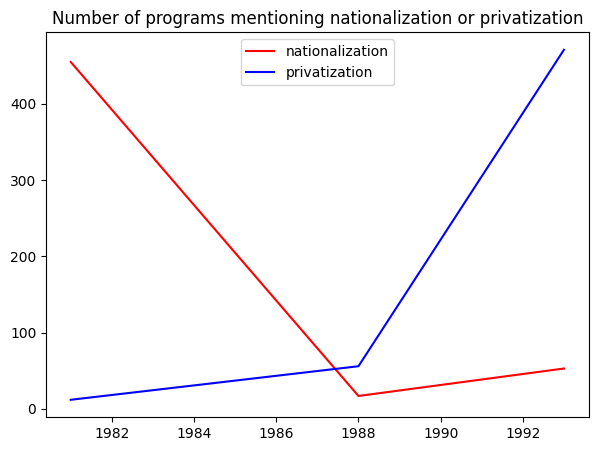

In [92]:
fig, ax = plt.subplots(figsize=(7, 5))

x1=[nat_1981, nat_1988, nat_1993]
x2=[priv_1981, priv_1988, priv_1993]

y=[1981, 1988, 1993]
ax.plot(y, x1, color="red", label="nationalization")
ax.plot(y, x2, color="blue", label="privatization")
ax.set_title("Number of programs mentioning nationalization or privatization")
ax.legend(loc="upper center")
plt.show()

We can see that there is a shift in the use of both terms: the words associated with "privatization" replace the words associated with "nationalization" as the elections go on.

Now let us see the evolution of the terms used by each affiliation.

In [93]:
df["affiliation"].value_counts()

affiliation
far-left        445
unaffiliated    206
right           197
left            157
far-right        25
Name: count, dtype: int64

In [94]:
# far-left
fl_nat=(len(df[(df["affiliation"]=="far-left") & (df["nat"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="far-left") & (df["nat"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="far-left") & (df["nat"]==True) & (df["year"]==1993)]))
fl_priv=(len(df[(df["affiliation"]=="far-left") & (df["priv"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="far-left") & (df["priv"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="far-left") & (df["priv"]==True) & (df["year"]==1993)]))

# left
l_nat=(len(df[(df["affiliation"]=="left") & (df["nat"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="left") & (df["nat"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="left") & (df["nat"]==True) & (df["year"]==1993)]))
l_priv=(len(df[(df["affiliation"]=="left") & (df["priv"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="left") & (df["priv"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="left") & (df["priv"]==True) & (df["year"]==1993)]))

# center
c_nat=(len(df[(df["affiliation"]=="center") & (df["nat"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="center") & (df["nat"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="center") & (df["nat"]==True) & (df["year"]==1993)]))
c_priv=(len(df[(df["affiliation"]=="center") & (df["priv"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="center") & (df["priv"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="center") & (df["priv"]==True) & (df["year"]==1993)]))

# right
r_nat=(len(df[(df["affiliation"]=="right") & (df["nat"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="right") & (df["nat"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="right") & (df["nat"]==True) & (df["year"]==1993)]))
r_priv=(len(df[(df["affiliation"]=="right") & (df["priv"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="right") & (df["priv"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="right") & (df["priv"]==True) & (df["year"]==1993)]))


# far-right
fr_nat=(len(df[(df["affiliation"]=="far-right") & (df["nat"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="far-right") & (df["nat"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="far-right") & (df["nat"]==True) & (df["year"]==1993)]))
fr_priv=(len(df[(df["affiliation"]=="far-right") & (df["priv"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="far-right") & (df["priv"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="far-right") & (df["priv"]==True) & (df["year"]==1993)]))

# unaffiliated
u_nat=(len(df[(df["affiliation"]=="unaffiliated") & (df["nat"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="unaffiliated") & (df["nat"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="unaffiliated") & (df["nat"]==True) & (df["year"]==1993)]))
u_priv=(len(df[(df["affiliation"]=="unaffiliated") & (df["priv"]==True) & (df["year"]==1981)]), len(df[(df["affiliation"]=="unaffiliated") & (df["priv"]==True) & (df["year"]==1988)]), len(df[(df["affiliation"]=="unaffiliated") & (df["priv"]==True) & (df["year"]==1993)]))

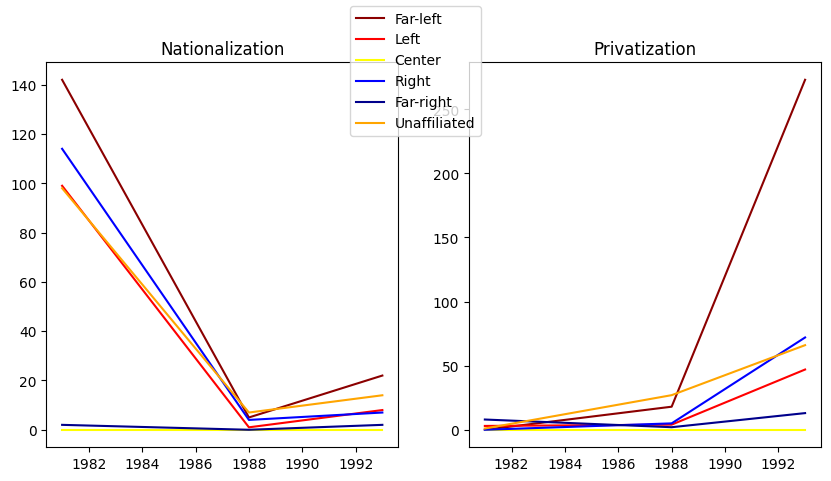

In [95]:
# Use of the terms by affiliation and by year
fig, ax = plt.subplots(1, 2, figsize=(10,5))
years=[1981, 1988, 1993]

nat={"far-left":fl_nat}
ax[0].plot(years, fl_nat, color="darkred", label="far-left")
ax[1].plot(years, fl_priv, color="darkred", label="far-left")

ax[0].plot(years, l_nat, color="red", label="left")
ax[1].plot(years, l_priv, color="red", label="left")

ax[0].plot(years, c_nat, color="yellow", label="center")
ax[1].plot(years, c_priv, color="yellow", label="center")

ax[0].plot(years, r_nat, color="blue", label="right")
ax[1].plot(years, r_priv, color="blue", label="right")

ax[0].plot(years, fr_nat, color="darkblue", label="far-right")
ax[1].plot(years, fr_priv, color="darkblue", label="far-right")

ax[0].plot(years, u_nat, color="orange", label="unaffiliated")
ax[1].plot(years, u_priv, color="orange", label="unaffiliated")

ax[0].set_title("Nationalization")
ax[1].set_title("Privatization")

fig.legend(handles=[fl_nat[0], l_nat[0], c_nat[0], r_nat[0], fr_nat[0], u_nat[0]], labels=('Far-left', 'Left', "Center", "Right", "Far-right", "Unaffiliated"), loc='upper center')

We can plot the number of phrases for each department, to see if some departments are more opinionated on this debate than others.

In [ ]:
df=pd.read_csv("data/df_phrases.csv")

In [259]:
departments_borders = carti_download(
            values = ["France"],
            crs = 4326,
            borders = "DEPARTEMENT",
            vectorfile_format="geojson",
            simplification=50,
            filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
            source="EXPRESS-COG-CARTO-TERRITOIRE",
            year=2022)
departments_borders["LIBELLE_DEPARTEMENT"]=departments_borders["LIBELLE_DEPARTEMENT"].astype(str)

In [263]:
departments_phrases=df.groupby('locality-nom')['text'].count().reset_index()
departments_phrases=departments_phrases.rename(columns={"locality-nom":"LIBELLE_DEPARTEMENT"})
departments_phrases["LIBELLE_DEPARTEMENT"]=departments_phrases["LIBELLE_DEPARTEMENT"].astype(str)

In [264]:
departments_borders=departments_borders.merge(departments_phrases, on="LIBELLE_DEPARTEMENT", how="left")
departments_borders["text"]=departments_borders["text"].fillna(0)

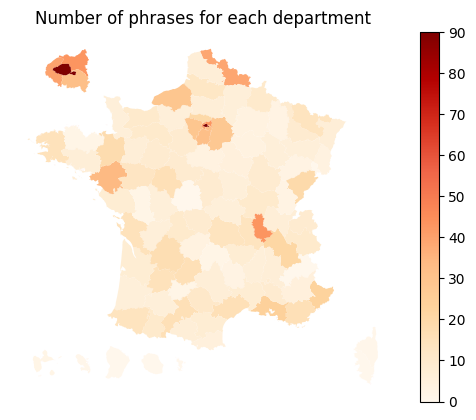

In [265]:
ax=departments_borders.plot(column="text", legend=True, cmap='OrRd')
ax.set_axis_off()
ax.set_title("Number of phrases involving the topic for each department")
plt.show()

Finally we can do some topic modeling to see which words nationalization and privatization are associated with, notably which type of institutions are nationalized or privatized.

In [ ]:
df=pd.read_csv("data/df_phrases.csv")

In [353]:
def plot_top_words(model, vectorizer, n_top_words, title, nb_lines=2):
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(nb_lines, 5, figsize=(30, 30), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

In [364]:
n_features = 1000
n_topics = 10
STOPWORDS = [x.strip() for x in open('stop_word_fr.txt').readlines()] + keywords_nat + keywords_priv + ["nationalisation", "nationaliser", "privatisation", "privatiser", "étatisation", "étatiser"]
nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
df['lemmatized_text'] = [" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(df['text'])]

/home/baloon0312/ml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etatisa', 'etatise', 'etatiso', 'etatisé', 'nationalisa', 'nationalise', 'nationaliso', 'nationalisé', 'privatisa', 'privatise', 'privatiso', 'privatisé', 'quelqu', 'étatisa', 'étatise', 'étatiso', 'étatisé'] not in stop_words.
  warnings.warn(


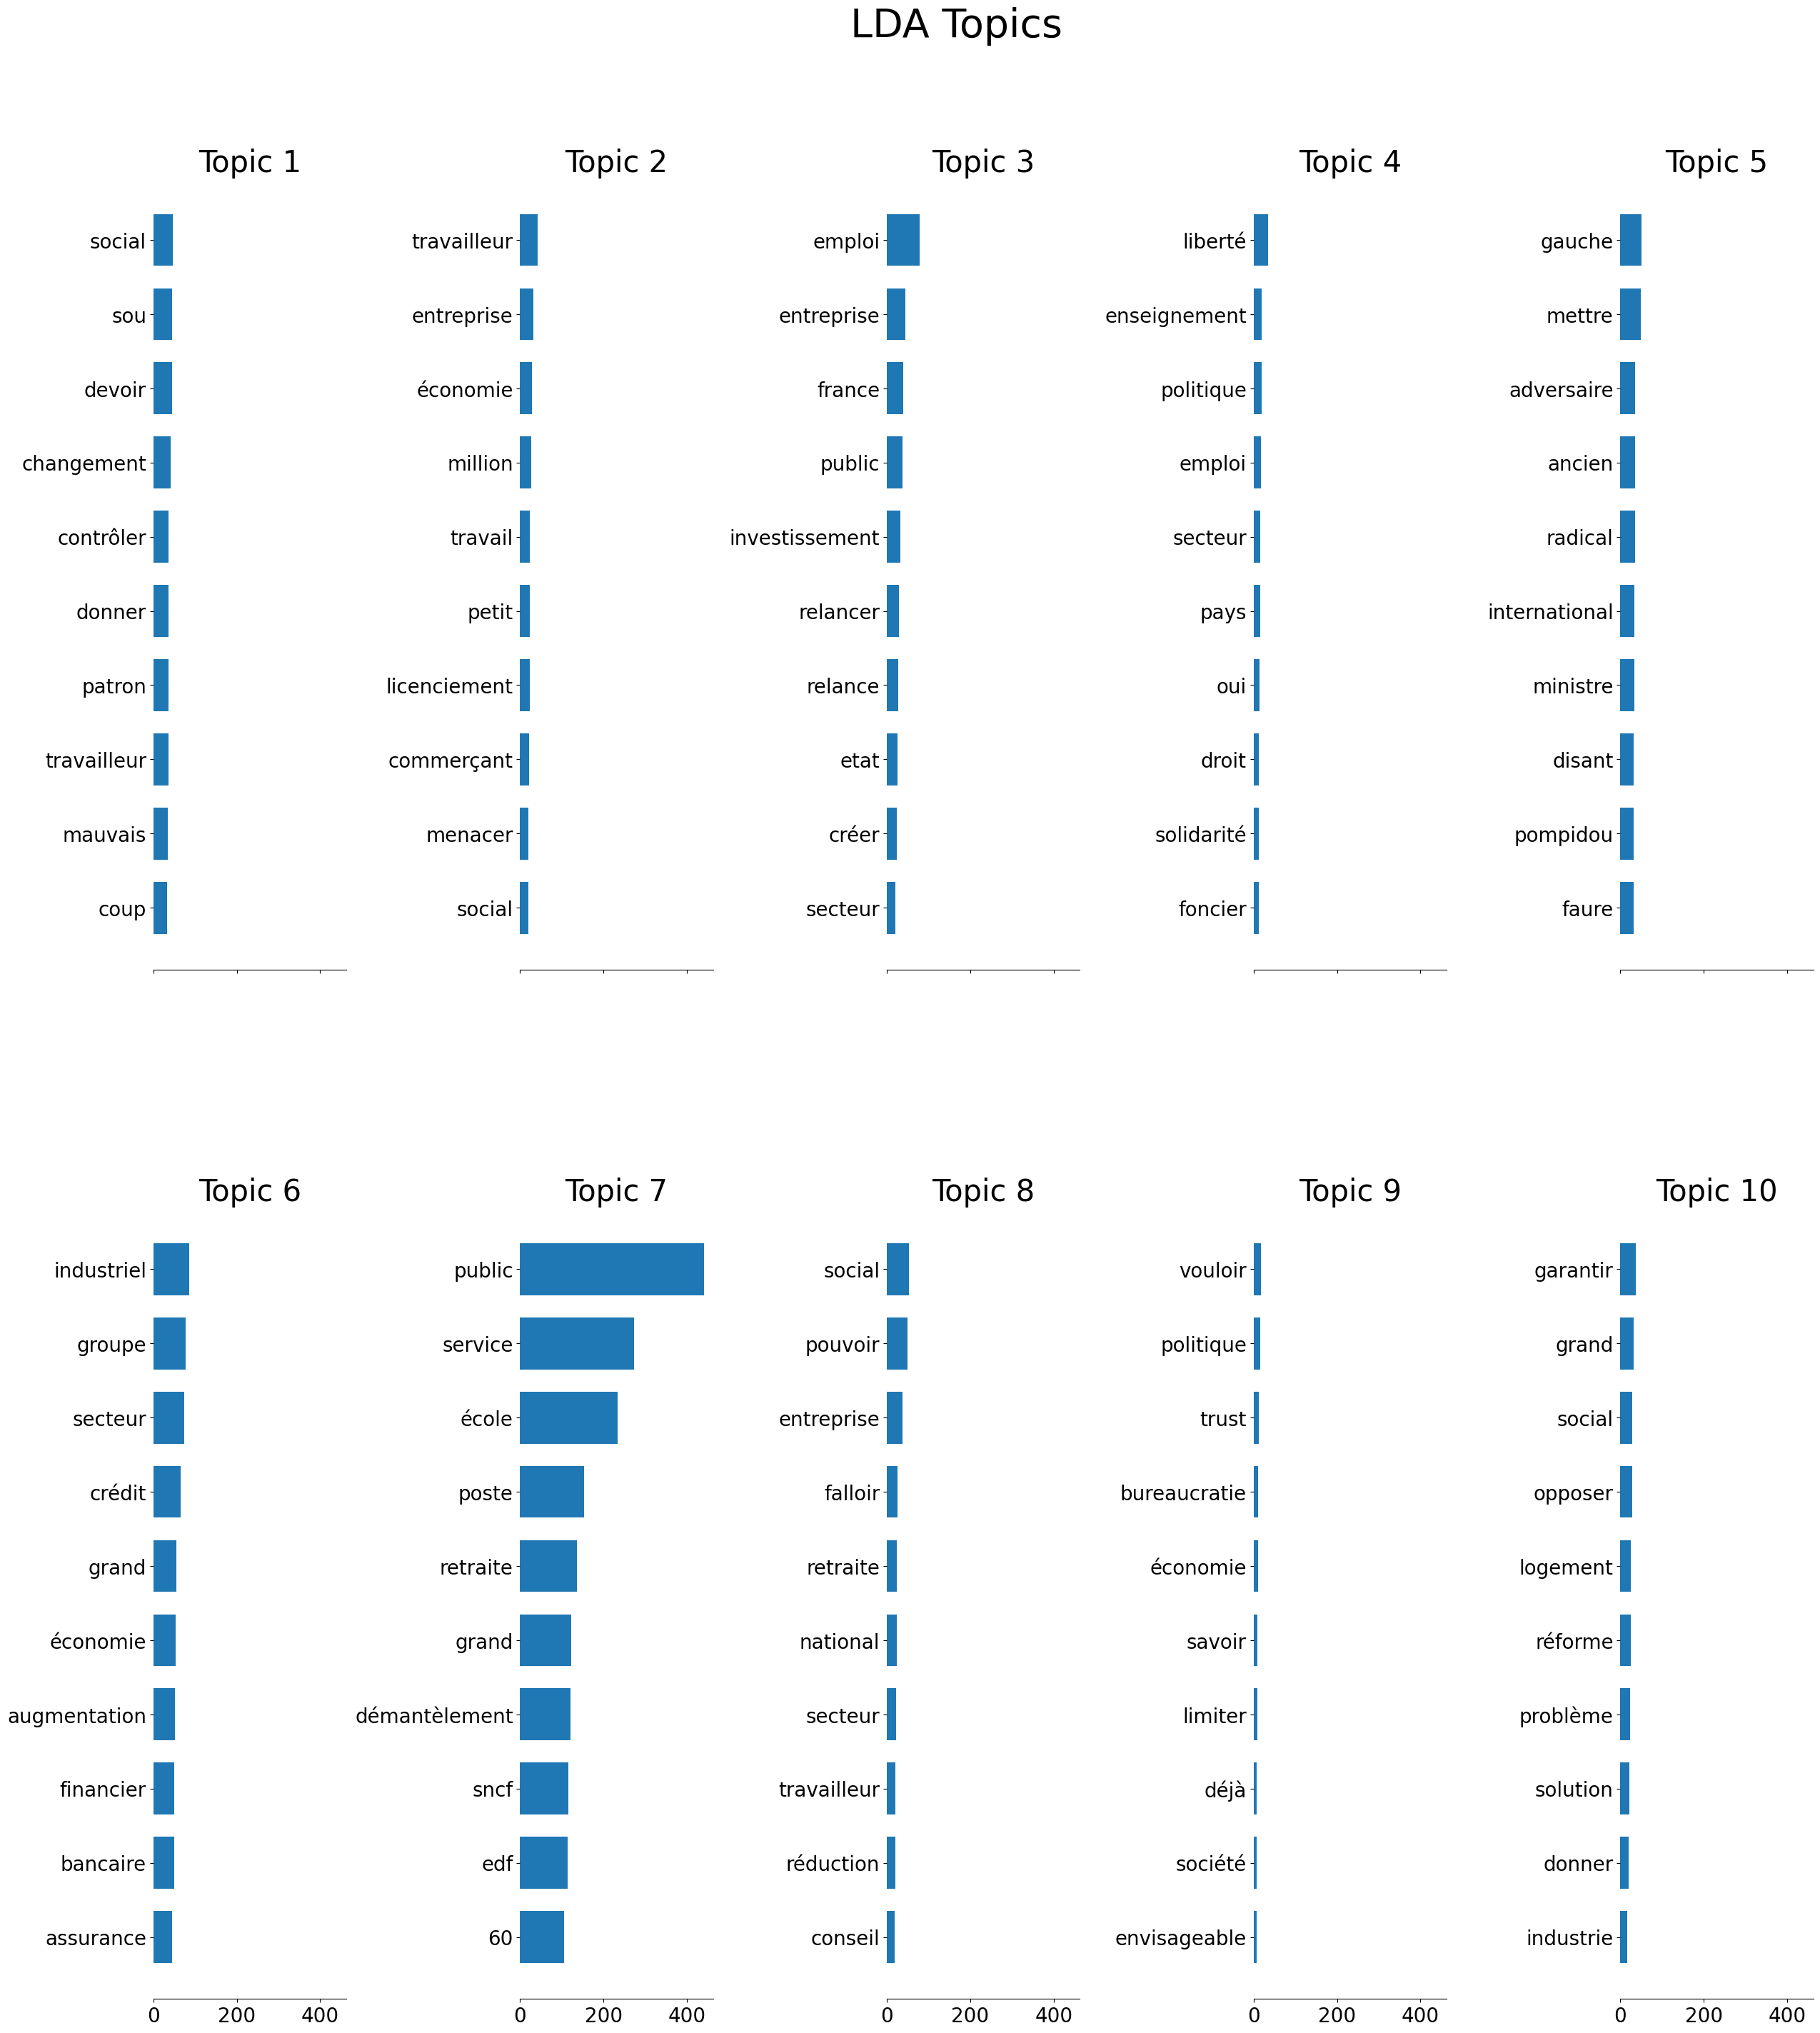

In [365]:
count=CountVectorizer(stop_words=STOPWORDS)
X=count.fit_transform(df["lemmatized_text"])
lda=LatentDirichletAllocation()
lda.fit(X)

# visualize the words in topics
plot_top_words(lda, count, 10, "LDA Topics")

# Sentiment analysis using pre-trained BERT models and LLMs

In this section I load two pre-trained models and test them on the annotated test set to keep the most performant model. I also test a LLM.

In [2]:
test_set=pd.read_csv("data/test_set.csv")

## Model 1: baseline BERT

In [3]:
# BERT and batch processing
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

MAX_LEN = 512

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

In [ ]:
# Batched BERT prediction function
def bert_predict_classes(texts, batch_size=32):
    
    preds = []

    for i in range(0, len(texts), batch_size):

        batch_texts = texts[i:i+batch_size]
        

        enc = tokenizer(
            list(batch_texts),
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits

        
        batch_preds = torch.argmax(logits, dim=1).cpu().numpy() + 1
        preds.extend(batch_preds)

    return np.array(preds)

In [5]:
texts = test_set['text'].astype(str).tolist()
test_set['sentiment_test'] = bert_predict_classes(texts, batch_size=32) 

0


In [6]:
test_set["sentiment_test"]

0      1
1      4
2      5
3      1
4      4
      ..
116    1
117    1
118    4
119    1
120    2
Name: sentiment_test, Length: 121, dtype: int64

In [7]:
test_set["sentiment_test"] = test_set["sentiment_test"].map({1:1, 2:1, 3:2, 4:3, 5:3})

In [116]:
print(classification_report(test_set["sentiment"], test_set["sentiment_test"]))

              precision    recall  f1-score   support

           1       0.82      0.57      0.67        81
           2       0.31      0.62      0.42         8
           3       0.45      0.69      0.54        32

    accuracy                           0.60       121
   macro avg       0.53      0.63      0.54       121
weighted avg       0.69      0.60      0.62       121



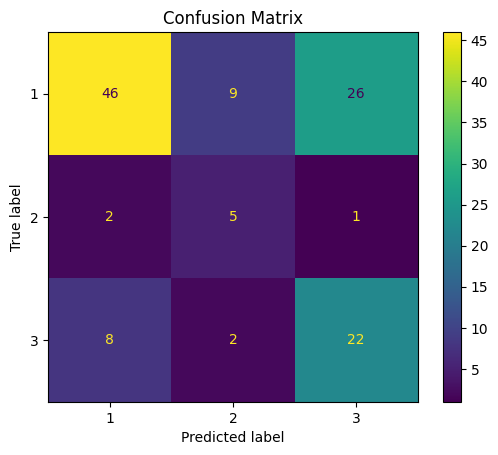

In [115]:
cm = confusion_matrix(test_set["sentiment"], test_set["sentiment_test"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Model 2: BERT fine-tuned on French Sentiment Analysis

In [8]:
# BERT and batch processing
model_name = "ac0hik/Sentiment_Analysis_French"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

MAX_LEN = 512

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [9]:
test_set['sentiment_test_2'] = bert_predict_classes(texts, batch_size=32) 

0


In [10]:
print(classification_report(test_set["sentiment"], test_set["sentiment_test_2"]))

              precision    recall  f1-score   support

           1       0.88      0.84      0.86        81
           2       0.00      0.00      0.00         8
           3       0.64      0.78      0.70        32

    accuracy                           0.77       121
   macro avg       0.51      0.54      0.52       121
weighted avg       0.76      0.77      0.76       121



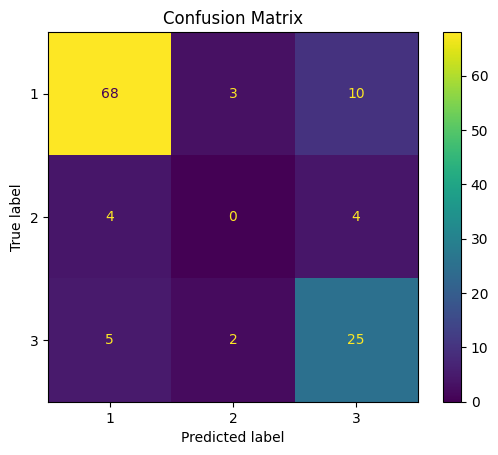

In [94]:
cm = confusion_matrix(test_set["sentiment"], test_set["sentiment_test_2"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

The prediction of neutral statements is not good, but these statements are a minority and of less interest than the positive and negative satements, which are relatively correctly predicted.

## Model 3: Llama

This part requires an API key for the ENSAE LLM lab. Explanations on how to create a token with a ENSAE account can be found here: https://documentation-dsit.lab.groupe-genes.fr/Services/Datalab/LLM%20%28Ollama-WebUI%29/.

The version of the test_set.csv file available in the repository has all the ratings provided by the LLM, so it is not necessary to reproduce this step in order to perform the following ones.

In [ ]:
apikey=input("api key")

In [9]:
url = "https://llm.lab.groupe-genes.fr/ollama/api/chat"
for i in tqdm(range((len(test_set)))):
    
    
    payload = {
        "model": "llama3.3:latest",
        "messages": [
            {"role": "system", "content": "Tu es un chercheur en sciences politiques CONCIS. \n"
             "Analyse la phrase suivante et donne son sentiment sur la privatisation ou la nationalisation.\n" 
             "1 = NÉGATIF, 2 = NEUTRE, 3 = POSITIF. \n"
            "Output : <entier 1–3> \n"
            "Ne donne qu'une note sans aucune explication."},
            {"role": "user", "content": test_set.loc[i,"text"]}
         ],
        "stream": False,
        "temperature":0}

    r = requests.post(url,
                      headers={
        "Authorization": f"Bearer {apikey}",
        "Content-Type": "application/json"
    },
                      json=payload, timeout=90, verify=False)
    r.raise_for_status()
    rating=findall("\d", r.json()["message"]["content"])[0] # isolate the number in case the LLM generates text
    test_set.loc[i, "sentiment_test_3"]=int(rating)
    last_treated=i

100%|███████████████████████████████████████████████| 121/121 [04:01<00:00,  1.99s/it]


In [10]:
print(classification_report(test_set["sentiment"], test_set["sentiment_test_3"]))

              precision    recall  f1-score   support

           1       0.95      0.94      0.94        81
           2       0.44      0.50      0.47         8
           3       0.84      0.84      0.84        32

    accuracy                           0.88       121
   macro avg       0.75      0.76      0.75       121
weighted avg       0.89      0.88      0.89       121



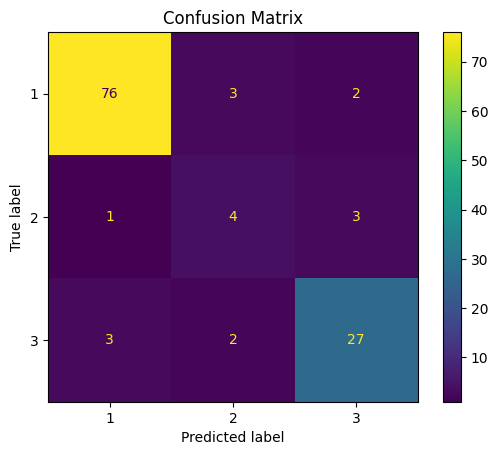

In [11]:
cm = confusion_matrix(test_set["sentiment"], test_set["sentiment_test_3"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

The LLM yields the best classification performances, therefore we can use it to classify the whole sample.

In [11]:
test_set.to_csv("data/test_set.csv")

# Classified texts analysis

First I use the LLM to classify all phrases in the dataset. As previously stated, this step requires an API token, but the classified dataset is available as the df_phrases.csv file.

In [ ]:
df=pd.read_csv("data/df_phrases.csv")

In [50]:
last_treated=0 # in case the LLM has a bug

In [52]:
url = "https://llm.lab.groupe-genes.fr/ollama/api/chat"
for i in tqdm(range((len(test_set)))):
    
    
    payload = {
        "model": "llama3.3:latest",
        "messages": [
            {"role": "system", "content": "Tu es un chercheur en sciences politiques CONCIS. \n"
             "Analyse la phrase suivante et donne son sentiment sur la privatisation ou la nationalisation.\n" 
             "1 = NÉGATIF, 2 = NEUTRE, 3 = POSITIF. \n"
            "Output : <entier 1–3> \n"
            "Ne donne qu'une note sans aucune explication."},
            {"role": "user", "content": test_set.loc[i,"text"]}
         ],
        "stream": False,
        "temperature":0}

    r = requests.post(url,
                      headers={
        "Authorization": f"Bearer {apikey}",
        "Content-Type": "application/json"
    },
                      json=payload, timeout=90, verify=False)
    r.raise_for_status()
    rating=findall("\d", r.json()["message"]["content"])[0] # isolate the number in case the LLM generates text
    test_set.loc[i, "sentiment_test_3"]=int(rating)
    last_treated=i

100%|█████████████████████████████████████████████| 1211/1211 [42:39<00:00,  2.11s/it]


In [ ]:
df.to_csv("data/df_phrases.csv")

## Sentiment score of a party/block

In [ ]:
df=pd.read_csv("data/df_phrases.csv")

In [13]:
df["sentiment"].value_counts()

sentiment
1.0    705
3.0    391
2.0    115
Name: count, dtype: int64

Here I change the sentiment ratings in order to create a sentiment score summing the sentiment of each phrase of a party/block. Negative phrases get a -1 rating, neutral phrases get a 0 score and positive phrases get a 1 score.

In [109]:
df["sentiment"]=df["sentiment"].replace(1, -1)
df["sentiment"]=df["sentiment"].replace(2, 0)
df["sentiment"]=df["sentiment"].replace(3, 1)

Then I separate phrases about privatization and nationalization in order to get a score for each political block.

In [30]:
df_nat_fl=df[(df["nat"]==True) & (df["affiliation"]=="far-left")]
df_nat_l=df[(df["nat"]==True) & (df["affiliation"]=="left")]
df_nat_c=df[(df["nat"]==True) & (df["affiliation"]=="center")]
df_nat_r=df[(df["nat"]==True) & (df["affiliation"]=="right")]
df_nat_fr=df[(df["nat"]==True) & (df["affiliation"]=="far-right")]
df_nat_u=df[(df["nat"]==True) & (df["affiliation"]=="unaffiliated")]

df_priv_fl=df[(df["priv"]==True) & (df["affiliation"]=="far-left")]
df_priv_l=df[(df["priv"]==True) & (df["affiliation"]=="left")]
df_priv_c=df[(df["priv"]==True) & (df["affiliation"]=="center")]
df_priv_r=df[(df["priv"]==True) & (df["affiliation"]=="right")]
df_priv_fr=df[(df["priv"]==True) & (df["affiliation"]=="far-right")]
df_priv_u=df[(df["priv"]==True) & (df["affiliation"]=="unaffiliated")]

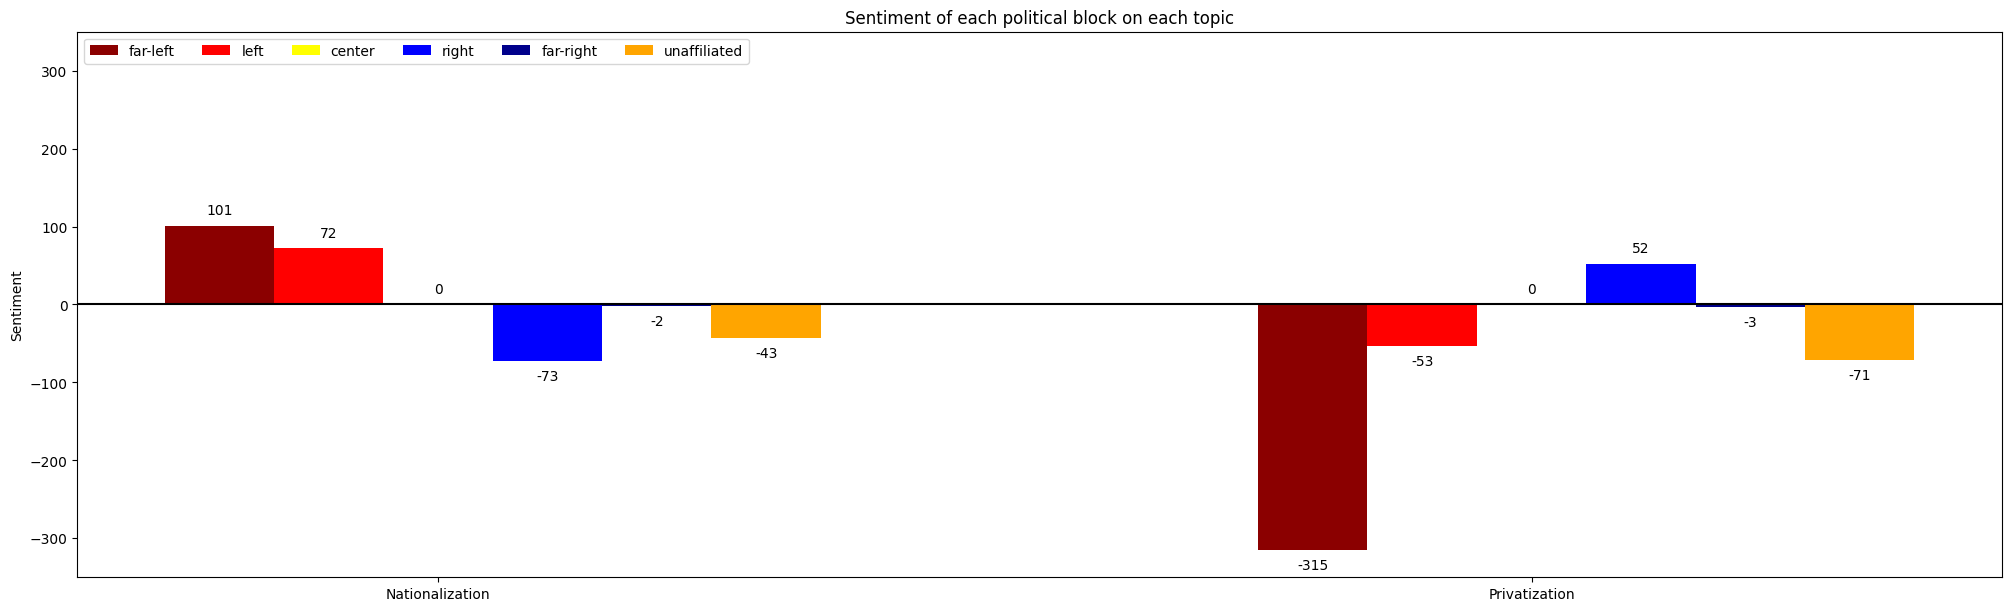

In [274]:
themes=("Nationalization", "Privatization")
sentiments={"far-left":(df_nat_fl["sentiment"].sum(), df_priv_fl["sentiment"].sum()),
            "left":(df_nat_l["sentiment"].sum(), df_priv_l["sentiment"].sum()),
            "center":(df_nat_c["sentiment"].sum(), df_priv_c["sentiment"].sum()),
            "right":(df_nat_r["sentiment"].sum(), df_priv_r["sentiment"].sum()),
            "far-right":(df_nat_fr["sentiment"].sum(), df_priv_fr["sentiment"].sum()),
            "unaffiliated":(df_nat_u["sentiment"].sum(), df_priv_u["sentiment"].sum())
           
           }

x = np.arange(len(themes))  
width = 0.1  
multiplier = 2
colors=["darkred", "red", "yellow", "blue", "darkblue", "orange"]
col_count=0
fig, ax = plt.subplots(layout='constrained', figsize=(20,6))

for parti, score, in sentiments.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, score, width, label=parti, color=colors[col_count])
    ax.bar_label(rects, padding=6)
    multiplier += 1
    col_count +=1

    
ax.set_ylabel('Sentiment')
ax.set_title('Sentiment of each political block on each topic')
ax.set_xticks(x + 0.4, themes)
ax.legend(loc='upper left', ncols=6)
ax.set_ylim(-350, 350)
plt.axhline(y=0, color="black")

plt.show()

We can also conduct this analysis with the most important parties.

In [79]:
df_nat_pcf=df[(df["nat"]==True) & (df["pcf"]==True)]
df_nat_ps=df[(df["nat"]==True) & (df["ps"]==True)]
df_nat_rpr=df[(df["nat"]==True) & (df["rpr"]==True)]
df_nat_udf=df[(df["nat"]==True) & (df["udf"]==True)]

df_priv_pcf=df[(df["priv"]==True) & (df["pcf"]==True)]
df_priv_ps=df[(df["priv"]==True) & (df["ps"]==True)]
df_priv_rpr=df[(df["priv"]==True) & (df["rpr"]==True)]
df_priv_udf=df[(df["priv"]==True) & (df["udf"]==True)]


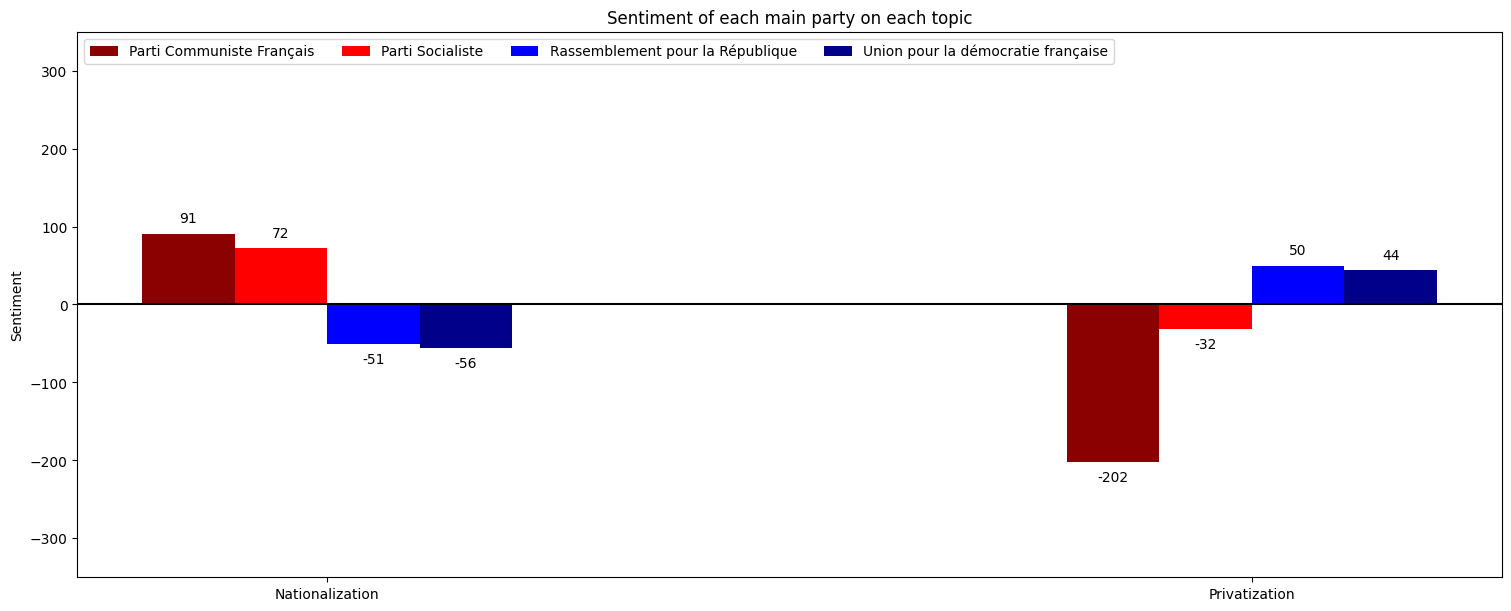

In [273]:
themes=("Nationalization", "Privatization")
sentiments={"Parti Communiste Français":(df_nat_pcf["sentiment"].sum(), df_priv_pcf["sentiment"].sum()),
            "Parti Socialiste":(df_nat_l["sentiment"].sum(), df_priv_ps["sentiment"].sum()),
            "Rassemblement pour la République":(df_nat_rpr["sentiment"].sum(), df_priv_rpr["sentiment"].sum()),
            "Union pour la démocratie française":(df_nat_udf["sentiment"].sum(), df_priv_udf["sentiment"].sum()),
           }

x = np.arange(len(themes))  
width = 0.1  
multiplier = 2
colors=["darkred", "red", "blue", "darkblue"]
col_count=0
fig, ax = plt.subplots(layout='constrained', figsize=(15,6))

for parti, score, in sentiments.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, score, width, label=parti, color=colors[col_count])
    ax.bar_label(rects, padding=6)
    multiplier += 1
    col_count +=1

    
ax.set_ylabel('Sentiment')
ax.set_title('Sentiment of each main party on each topic')
ax.set_xticks(x + 0.35, themes)
ax.legend(loc='upper left', ncols=6)
ax.set_ylim(-350, 350)
plt.axhline(y=0, color="black")

plt.show()

Then we can see how intense each block or party's sentiment about one of the topic is for each election.

In [112]:
# far-left
fl_nat=(df[(df["affiliation"]=="far-left") & (df["nat"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="far-left") & (df["nat"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="far-left") & (df["nat"]==True) & (df["year"]==1993)]["sentiment"].sum())
fl_priv=(df[(df["affiliation"]=="far-left") & (df["priv"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="far-left") & (df["priv"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="far-left") & (df["priv"]==True) & (df["year"]==1993)]["sentiment"].sum())

# left
l_nat=(df[(df["affiliation"]=="left") & (df["nat"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="left") & (df["nat"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="left") & (df["nat"]==True) & (df["year"]==1993)]["sentiment"].sum())
l_priv=(df[(df["affiliation"]=="left") & (df["priv"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="left") & (df["priv"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="left") & (df["priv"]==True) & (df["year"]==1993)]["sentiment"].sum())

# center
c_nat=(df[(df["affiliation"]=="center") & (df["nat"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="center") & (df["nat"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="center") & (df["nat"]==True) & (df["year"]==1993)]["sentiment"].sum())
c_priv=(df[(df["affiliation"]=="center") & (df["priv"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="center") & (df["priv"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="center") & (df["priv"]==True) & (df["year"]==1993)]["sentiment"].sum())

# right
r_nat=(df[(df["affiliation"]=="right") & (df["nat"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="right") & (df["nat"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="right") & (df["nat"]==True) & (df["year"]==1993)]["sentiment"].sum())
r_priv=(df[(df["affiliation"]=="right") & (df["priv"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="right") & (df["priv"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="right") & (df["priv"]==True) & (df["year"]==1993)]["sentiment"].sum())

# far-right
fr_nat=(df[(df["affiliation"]=="far-right") & (df["nat"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="far-right") & (df["nat"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="far-right") & (df["nat"]==True) & (df["year"]==1993)]["sentiment"].sum())
fr_priv=(df[(df["affiliation"]=="far-right") & (df["priv"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="far-right") & (df["priv"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="far-right") & (df["priv"]==True) & (df["year"]==1993)]["sentiment"].sum())

# unaffiliated
u_nat=(df[(df["affiliation"]=="unaffiliated") & (df["nat"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="unaffiliated") & (df["nat"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="unaffiliated") & (df["nat"]==True) & (df["year"]==1993)]["sentiment"].sum())
u_priv=(df[(df["affiliation"]=="unaffiliated") & (df["priv"]==True) & (df["year"]==1981)]["sentiment"].sum(), df[(df["affiliation"]=="unaffiliated") & (df["priv"]==True) & (df["year"]==1988)]["sentiment"].sum(), df[(df["affiliation"]=="unaffiliated") & (df["priv"]==True) & (df["year"]==1993)]["sentiment"].sum())


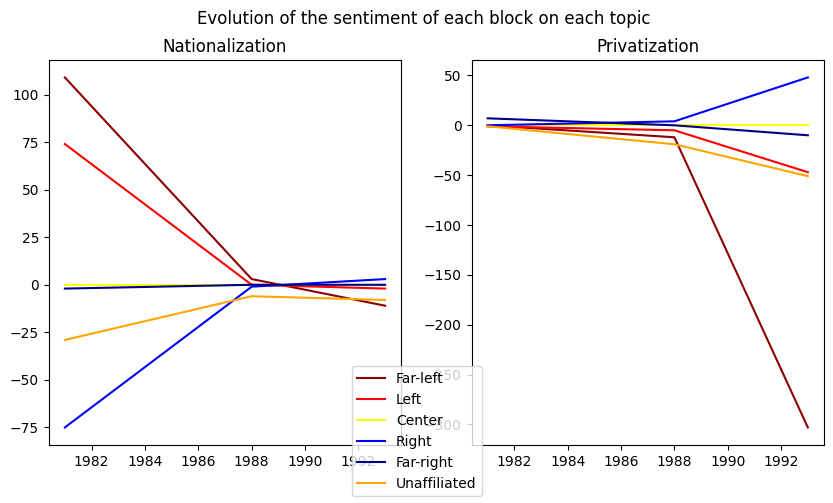

In [129]:
# Use of the terms by affiliation and by year
fig, ax = plt.subplots(1, 2, figsize=(10,5))
years=[1981, 1988, 1993]

nat={"far-left":fl_nat}
ax[0].plot(years, fl_nat, color="darkred", label="far-left")
ax[1].plot(years, fl_priv, color="darkred", label="far-left")

ax[0].plot(years, l_nat, color="red", label="left")
ax[1].plot(years, l_priv, color="red", label="left")

ax[0].plot(years, c_nat, color="yellow", label="center")
ax[1].plot(years, c_priv, color="yellow", label="center")

ax[0].plot(years, r_nat, color="blue", label="right")
ax[1].plot(years, r_priv, color="blue", label="right")

ax[0].plot(years, fr_nat, color="darkblue", label="far-right")
ax[1].plot(years, fr_priv, color="darkblue", label="far-right")

ax[0].plot(years, u_nat, color="orange", label="unaffiliated")
ax[1].plot(years, u_priv, color="orange", label="unaffiliated")

ax[0].set_title("Nationalization")
ax[1].set_title("Privatization")

fig.suptitle("Evolution of the sentiment of each block on each topic")
fig.legend(labels=('Far-left', 'Left', "Center", "Right", "Far-right", "Unaffiliated"), loc='lower center')

plt.show()


# Conclusion

This study used sentiment analysis methods in order to define the position of each political block on the nationalization vs. privatization debate, as well as the evolution of this stance over the years. We can see that the focus of the debate has shifted from nationalization to privatization, and that this debate is driven by the far-left block.